In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Input data
X = np.array(
    [
        [1.0, 1.0],
        [1.5, 2.0],
        [3.0, 4.0],
        [5.0, 7.0],
        [3.5, 5.0],
        [4.5, 5.0],
        [3.5, 4.5],
    ]
)

K = 2

In [ ]:
def compute_distance(point, centroid):
  return np.linalg.norm(point - centroid, ord=2)


def find_closest_centroid(point, centroids):
  distances = np.linalg.norm(centroids - point, axis=1)
  return np.argmin(distances)


def assign_clusters(X, centroids):
  idx = []
  for point in X:
    cluster = find_closest_centroid(point, centroids)
    idx.append(cluster)
  return np.array(idx)


def compute_centroids(X, idx, K):
  new_centroids = []
  for k in range(K):
    points = X[idx == k]
    if len(points) > 0:
      centroid = np.mean(points, axis=0)
    else:
      # Fallback if a cluster becomes empty
      centroid = X[np.random.choice(len(X))]
    new_centroids.append(centroid)
  return np.array(new_centroids)


def compute_cost(X, idx, centroids):
  m = len(X)
  total = 0.0
  for i in range(m):
    centroid = centroids[idx[i]]
    total += np.sum((X[i] - centroid) ** 2)
  return total / m

In [ ]:
def init_kmeans_plus_plus(X, K):
  np.random.seed(42)
  centroids = []

  # Step 1: Choose the first centroid uniformly at random
  first_idx = np.random.choice(len(X))
  centroids.append(X[first_idx])

  # Step 2: Select remaining K - 1 centroids
  for _ in range(1, K):
    # Compute squared distance D(x)^2 from each point to the nearest existing centroid
    min_dist_sq = []
    for x in X:
      dists = [np.sum((x - c) ** 2) for c in centroids]
      min_dist_sq.append(np.min(dists))

    min_dist_sq = np.array(min_dist_sq)

    # Compute selection probabilities proportional to D(x)^2
    probabilities = min_dist_sq / np.sum(min_dist_sq)

    # Choose next centroid based on the probability distribution
    next_idx = np.random.choice(len(X), p=probabilities)
    centroids.append(X[next_idx])

  return np.array(centroids)

In [ ]:
def run_kmeans_pp(X, K, max_iters=100):
  # 1. Initialize centroids using K-Means++
  centroids = init_kmeans_plus_plus(X, K)

  # 2. Standard Lloyd's iteration
  for i in range(max_iters):
    idx = assign_clusters(X, centroids)
    new_centroids = compute_centroids(X, idx, K)

    if np.allclose(new_centroids, centroids):
      break
    centroids = new_centroids

  return centroids, idx


# Run on the sample dataset
final_centroids, idx = run_kmeans_pp(X, K=2)
print("Final Centroids:\n", final_centroids)
print("Cluster Assignments:\n", idx)

Final Centroids:
 [[1.25 1.5 ]
 [3.9  5.1 ]]
Cluster Assignments:
 [0 0 1 1 1 1 1]


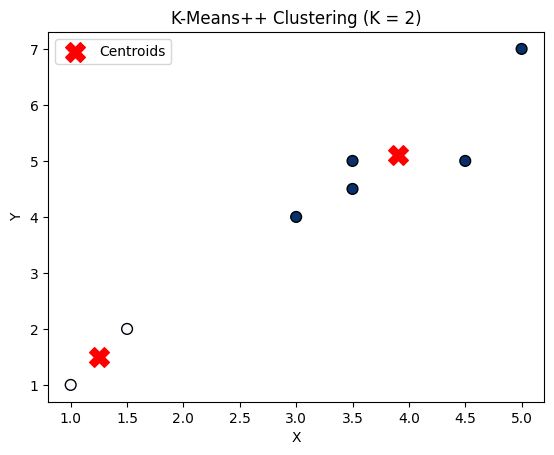

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=idx, s=60, cmap="Blues", edgecolors="k")
plt.scatter(
    final_centroids[:, 0],
    final_centroids[:, 1],
    marker="X",
    color="red",
    s=200,
    label="Centroids",
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("K-Means++ Clustering (K = 2)")
plt.legend()
plt.show()

Costs for K in [2, 3, 4]: [np.float64(1.2178571428571427), np.float64(0.35714285714285715), np.float64(0.1845238095238095)]


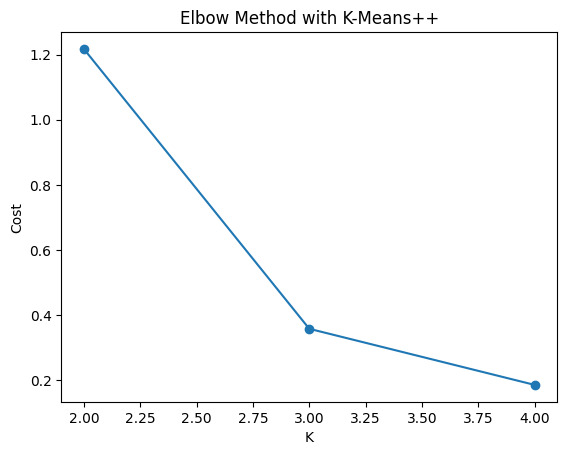

In [ ]:
costs = []
K_range = range(2, 5)

for k in K_range:
  # Run K-Means++
  centroids, idx = run_kmeans_pp(X, K=k, max_iters=200)

  # Compute final cost
  cost = compute_cost(X, idx, centroids)
  costs.append(cost)

print("Costs for K in [2, 3, 4]:", costs)

plt.plot(K_range, costs, marker="o")
plt.xlabel("K")
plt.ylabel("Cost")
plt.title("Elbow Method with K-Means++")
plt.show()